<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/akshyat_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.3 Monolingual vs. Multilingual - Sarcasm Detection


Research Question
Is XLM-RoBERTa better than RoBERTa at sarcasm detection on code-mixed en-IN?

Hypothesis
XLM-RoBERTa should perform better on en-IN due to better handling of Hindi-English mixing; differences on en-AU/en-UK should be small.

Setup
RoBERTa vs XLM-RoBERTa, trained on en-AU/en-IN/en-UK, 2 seeds, weighted loss for class imbalance.


In [1]:
!pip install transformers datasets scikit-learn torch matplotlib seaborn pandas numpy tqdm evaluate accelerate

In [2]:
import os, gc, time, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DataCollatorWithPadding, set_seed
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [3]:
TASK = "sarcasm"
VARIETIES = ["en-AU", "en-IN", "en-UK"]
DATASET_NAME = "surrey-nlp/BESSTIE-CW-26"
OUTPUT_DIR = "./outputs_2_3"
MONOLINGUAL_MODEL = "roberta-base"
MULTILINGUAL_MODEL = "xlm-roberta-base"
SEEDS = [555, 90210]
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5
LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
LABEL_NAMES = ["Not Sarcastic", "Sarcastic"]
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [4]:
ds = load_dataset(DATASET_NAME)
raw = {}
for v in VARIETIES:
    raw[v] = DatasetDict({split: ds[split].filter(lambda x: x["variety"] == v) for split in ds.keys()})
print(dict(raw["en-AU"]["train"][0]))


{'text': 'Yeah it blew out to 3x what it was budgeted for. Who wouldve thought giving people free cash to reovate their house would dry up resources for new builds...', 'variety': 'en-AU', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 1.0}


In [5]:
rows = []
for variety in VARIETIES:
    for split in ["train", "validation", "test"]:
        if split not in raw[variety]:
            continue
        d = raw[variety][split]
        n = len(d)
        lc = next((c for c in ["Sarcasm", "sarcasm_label", "sarcasm", "label"] if c in d.features), None)
        if lc:
            labels = [int(x) for x in d[lc]]
            c1, c0 = sum(labels), n - sum(labels)
        else:
            c0 = c1 = -1
        rows.append({"Variety": variety, "Split": split, "Total": n,
                     "Sarcastic": c1, "Not Sarcastic": c0,
                     "Imbalance": f"{c0/c1:.1f}:1" if c1 > 0 else "N/A"})
print(pd.DataFrame(rows).to_string(index=False))


Variety      Split  Total  Sarcastic  Not Sarcastic Imbalance
  en-AU      train   1145        337            808     2.4:1
  en-AU validation     95         28             67     2.4:1
  en-AU       test    667        196            471     2.4:1
  en-IN      train   1399         95           1304    13.7:1
  en-IN validation    117          8            109    13.6:1
  en-IN       test    816         56            760    13.6:1
  en-UK      train   1203         92           1111    12.1:1
  en-UK validation    101          8             93    11.6:1
  en-UK       test    700         53            647    12.2:1


In [6]:
def find_col(features, candidates):
    return next((c for c in candidates if c in features), None)

def prepare_split(raw_dict, varieties, task, split):
    parts = []
    for v in varieties:
        if v not in raw_dict or split not in raw_dict[v]:
            continue
        d = raw_dict[v][split]
        tc = find_col(d.features, ["text", "sentence", "review", "comment"])
        lc = find_col(d.features, [task.capitalize(), task + "_label", task, "label"])
        if not tc or not lc:
            print(f"skipping {v}/{split} columns: {list(d.features.keys())}")
            continue
        d = d.select_columns([tc, lc])
        if tc != "text": d = d.rename_column(tc, "text")
        if lc != "label": d = d.rename_column(lc, "label")
        d = d.add_column("variety", [v] * len(d))
        parts.append(d)
    return concatenate_datasets(parts)

train_ds = prepare_split(raw, VARIETIES, TASK, "train")
val_ds = prepare_split(raw, VARIETIES, TASK, "validation")
test_sets = {v: prepare_split(raw, [v], TASK, "test") for v in VARIETIES}

print("train:", len(train_ds), "val:", len(val_ds))
for v in test_sets:
    print("test", v, len(test_sets[v]))


train: 3747 val: 313
test en-AU 667
test en-IN 816
test en-UK 700


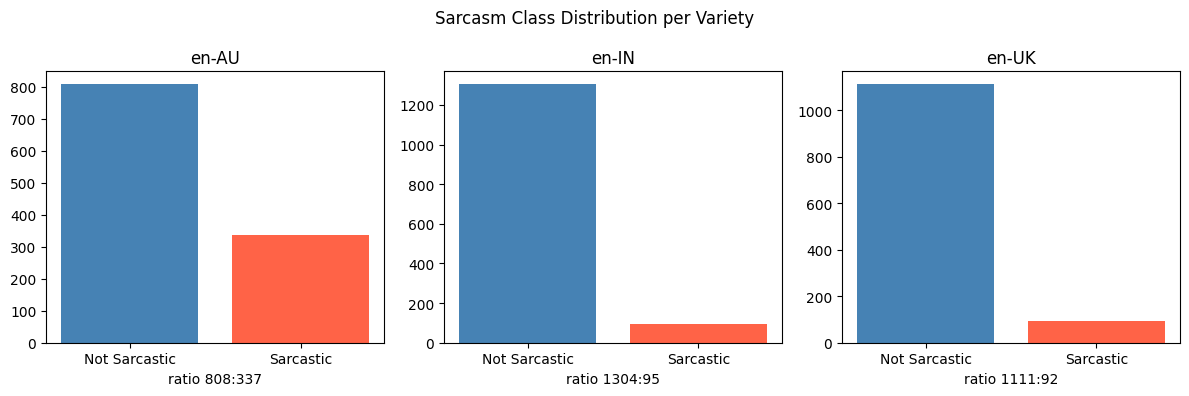

class weights: tensor([0.5813, 3.5754])


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, variety in enumerate(VARIETIES):
    d = raw[variety]["train"]
    lc = find_col(d.features, ["Sarcasm", "sarcasm_label", "sarcasm", "label"])
    counts = Counter(int(x) for x in d[lc])
    axes[i].bar(LABEL_NAMES, [counts[0], counts[1]], color=["steelblue", "tomato"])
    axes[i].set_title(variety)
    axes[i].set_xlabel(f"ratio {counts[0]}:{counts[1]}")
plt.suptitle("Sarcasm Class Distribution per Variety")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/class_dist.png", bbox_inches="tight")
plt.show()

all_labels = train_ds["label"]
n0 = sum(1 for l in all_labels if int(l) == 0)
n1 = sum(1 for l in all_labels if int(l) == 1)
class_weights = torch.tensor([len(all_labels)/(2*n0), len(all_labels)/(2*n1)], dtype=torch.float)
print("class weights:", class_weights)


found 70 code-mixed examples
[Not Sarcastic] ['raha'] - Dost dost na raha
[Not Sarcastic] ['hai'] - nah don't talk reason with these people. itna polarised ho chuke hai there is no
[Sarcastic] ['ghar'] - "Mai sath me Ghar chala rhi hu " /s hanji bilkul.. Aap apne paise hi khud pe spe
[Not Sarcastic] ['nahi', 'tha', 'raha'] - Mera Unemployment scheme implement nahi ho raha tha isiliye chod diya
[Not Sarcastic] ['hai', 'bhi'] - Har 3 mahine baad kisi bhi global celebrity ko bula lete hai for their own enter
[Not Sarcastic] ['bhi'] - Wo bhi test cricket m. Tea break k baad to tabahi hi macha denge wo!!!
[Sarcastic] ['nahi', 'hai'] - car crasher get to write essay on accidents
terrorists get to eat biryani on exc
[Not Sarcastic] ['nahi', 'hai', 'desh'] - > only problem is activism 
Desh chunautiyon se nahi chutiyo se pareshan hai mom
[Not Sarcastic] ['bhi'] - Udhar bhi jobless
[Not Sarcastic] ['hai'] - reddit ka facebook bana rakkha hai tum logo ne


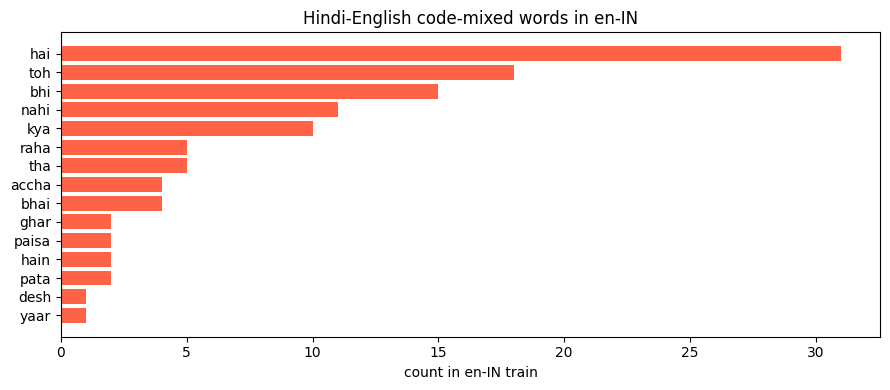

In [8]:
hindi_words = [
    "yaar", "nahi", "hai", "kya", "coz", "bhai", "chori", "zyada",
    "thoda", "bahut", "bilkul", "accha", "acha", "bas", "matlab",
    "lagta", "pata", "log", "desh", "ghar", "paisa", "sahi",
    "abhi", "toh", "bhi", "hain", "tha", "raha"
]

d = raw["en-IN"]["train"]
tc = find_col(d.features, ["text", "sentence", "review", "comment"])
lc = find_col(d.features, ["Sarcasm", "sarcasm_label", "sarcasm", "label"])

mixed, word_counts = [], []
for i in range(min(len(d), 10000)):
    row = d[i]
    found = [w for w in hindi_words if w in row[tc].lower().split()]
    if found:
        mixed.append({"text": row[tc], "label": LABEL_NAMES[int(row[lc])], "hindi": found})
        word_counts.extend(found)

print(f"found {len(mixed)} code-mixed examples")
for ex in mixed[:10]:
    print(f"[{ex['label']}] {ex['hindi']} - {ex['text'][:80]}")

words, cnts = zip(*Counter(word_counts).most_common(15))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(words)[::-1], list(cnts)[::-1], color="tomato")
ax.set_xlabel("count in en-IN train")
ax.set_title("Hindi-English code-mixed words in en-IN")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/code_mixing.png", bbox_inches="tight")
plt.show()


In [9]:
rob_tok = AutoTokenizer.from_pretrained(MONOLINGUAL_MODEL)
xlm_tok = AutoTokenizer.from_pretrained(MULTILINGUAL_MODEL)

test_phrases = [
    "Coz we all have free internet.",
    "Yaar this place is truly amazing!",
    "Bilkul sahi bola, great service.",
    "Bahut zyada crowd tha but food was okay.",
]

print("phrase token counts:")
for p in test_phrases:
    print(f"roberta={len(rob_tok.tokenize(p))} xlm={len(xlm_tok.tokenize(p))} {p}")

print()
print("word level tokenisation for hindi terms:")
for word in ["yaar", "chori", "bilkul", "bahut", "zyada", "bhai"]:
    print(f"  {word}")
    print(f"    roberta: {rob_tok.tokenize(word)}")
    print(f"    xlm-r:   {xlm_tok.tokenize(word)}")


phrase token counts:
roberta=8 xlm=8 Coz we all have free internet.
roberta=9 xlm=7 Yaar this place is truly amazing!
roberta=11 xlm=9 Bilkul sahi bola, great service.
roberta=12 xlm=11 Bahut zyada crowd tha but food was okay.

word level tokenisation for hindi terms:
  yaar
    roberta: ['ya', 'ar']
    xlm-r:   ['▁ya', 'ar']
  chori
    roberta: ['ch', 'ori']
    xlm-r:   ['▁cho', 'ri']
  bilkul
    roberta: ['bil', 'k', 'ul']
    xlm-r:   ['▁bil', 'kul']
  bahut
    roberta: ['bah', 'ut']
    xlm-r:   ['▁bahut']
  zyada
    roberta: ['zy', 'ada']
    xlm-r:   ['▁z', 'yada']
  bhai
    roberta: ['bh', 'ai']
    xlm-r:   ['▁bhai']


In [10]:
for name in [MONOLINGUAL_MODEL, MULTILINGUAL_MODEL]:
    m = AutoModelForSequenceClassification.from_pretrained(name, num_labels=2, ignore_mismatched_sizes=True)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name}: {n_params:,} params  ~{n_params*4/1e6:.0f}MB")
    del m
    gc.collect()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


roberta-base: 124,647,170 params  ~499MB


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


xlm-roberta-base: 278,045,186 params  ~1112MB


In [11]:
def tokenise_ds(ds, tokenizer):
    drop = ["text"]
    if "variety" in ds.column_names:
        drop.append("variety")
    tok = ds.map(
        lambda x: tokenizer(x["text"], truncation=True, padding=False, max_length=MAX_LEN),
        batched=True, remove_columns=drop
    )
    if "label" in tok.column_names:
        tok = tok.rename_column("label", "labels")
    tok = tok.map(lambda x: {"labels": int(x["labels"])})
    tok.set_format("torch")
    return tok


In [12]:
class WeightedTrainer(Trainer):
    def __init__(self, cw, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.cw = cw

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labs = inputs.pop("labels").long()
        out = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(weight=self.cw.to(out.logits.device))(out.logits, labs)
        return (loss, out) if return_outputs else loss


In [13]:
def compute_metrics(ep):
    preds = np.argmax(ep[0], axis=-1)
    _, _, f1, _ = precision_recall_fscore_support(ep[1], preds, average=None, labels=[0, 1])
    return {"macro_f1": f1_score(ep[1], preds, average="macro"),
            "f1_not_sarcastic": f1[0], "f1_sarcastic": f1[1]}


In [14]:
def eval_on_varieties(model, tokenizer, test_sets_dict):
    model.eval()
    results = {}
    for variety, ds in test_sets_dict.items():
        d = ds.remove_columns(["variety"]) if "variety" in ds.column_names else ds
        tok = tokenise_ds(d, tokenizer)
        loader = DataLoader(tok, batch_size=BATCH_SIZE, collate_fn=DataCollatorWithPadding(tokenizer))
        p_list, l_list = [], []
        with torch.no_grad():
            for batch in loader:
                l = batch.pop("labels").numpy()
                p = torch.argmax(model(**{k: v.to(device) for k, v in batch.items()}).logits, dim=-1).cpu().numpy()
                p_list.extend(p); l_list.extend(l)
        mf1 = f1_score(l_list, p_list, average="macro")
        results[variety] = {
            "macro_f1": mf1, "preds": p_list, "labels": l_list,
            "report": classification_report(l_list, p_list, target_names=LABEL_NAMES, output_dict=True, zero_division=0)
        }
        print(f"  {variety}: {mf1:.4f}")
    return results


In [15]:
def finetune(model_name, seed, tag, train_ds, val_ds, test_sets, cw):
    print(f"\nstarting {tag}...")
    set_seed(seed)

    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True).to(device)

    tr = tokenise_ds(train_ds, tok)
    va = tokenise_ds(val_ds, tok)

    trainer = WeightedTrainer(
        cw=cw, model=model,
        args=TrainingArguments(
            output_dir=OUTPUT_DIR + "/" + tag,
            num_train_epochs=EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            learning_rate=LR,
            warmup_steps=int(WARMUP_RATIO * (len(tr) // BATCH_SIZE) * EPOCHS),
            weight_decay=WEIGHT_DECAY,
            eval_strategy="epoch", save_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="macro_f1",
            greater_is_better=True, logging_steps=50, seed=seed,
            fp16=torch.cuda.is_available(), report_to="none", save_total_limit=1
        ),
        train_dataset=tr, eval_dataset=va,
        processing_class=tok,
        data_collator=DataCollatorWithPadding(tok),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    t0 = time.time()
    trainer.train()
    mins = (time.time() - t0) / 60
    best_f1 = trainer.state.best_metric
    print(f"done in {mins:.1f}min, best val f1={best_f1:.4f}")

    var_res = eval_on_varieties(trainer.model, tok, test_sets)

    combined = concatenate_datasets([
        ts.remove_columns(["variety"]) if "variety" in ts.column_names else ts
        for ts in test_sets.values()
    ])
    out = trainer.predict(tokenise_ds(combined, tok))
    all_p = np.argmax(out.predictions, axis=-1)
    overall = f1_score(out.label_ids, all_p, average="macro")
    print(f"overall: {overall:.4f}")
    print(classification_report(out.label_ids, all_p, target_names=LABEL_NAMES, zero_division=0))

    m = trainer.model
    del trainer; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {"tag": tag, "seed": seed, "val_f1": best_f1, "overall_f1": overall,
            "var_res": var_res, "preds": all_p, "labels": out.label_ids,
            "mins": mins, "model": m, "tok": tok}


In [16]:
rob_tok = AutoTokenizer.from_pretrained("reachaki/besstie-roberta-sarcasm")
rob_model = AutoModelForSequenceClassification.from_pretrained("reachaki/besstie-roberta-sarcasm").to(device)
rob_model.eval()

rob_var_results = eval_on_varieties(rob_model, rob_tok, test_sets)

combined_test = concatenate_datasets([
    ts.remove_columns(["variety"]) if "variety" in ts.column_names else ts
    for ts in test_sets.values()
])

tok_combined = tokenise_ds(combined_test, rob_tok)
loader = DataLoader(tok_combined, batch_size=BATCH_SIZE, collate_fn=DataCollatorWithPadding(rob_tok))

p_all, l_all = [], []
with torch.no_grad():
    for batch in loader:
        l = batch.pop("labels").numpy()
        p = torch.argmax(rob_model(**{k: v.to(device) for k, v in batch.items()}).logits, dim=-1).cpu().numpy()
        p_all.extend(p); l_all.extend(l)

rob_f1 = f1_score(l_all, p_all, average="macro")
print("overall macro-f1:", round(rob_f1, 4))
print(classification_report(l_all, p_all, target_names=LABEL_NAMES, zero_division=0))

roberta_run1 = {"tag": "rob_seed555", "seed": 555, "val_f1": 0.7189, "overall_f1": rob_f1,
                "var_res": rob_var_results, "preds": p_all, "labels": l_all,
                "mins": 3.0, "model": rob_model, "tok": rob_tok}

roberta_run2 = {"tag": "rob_seed90210", "seed": 90210, "val_f1": 0.6785, "overall_f1": 0.6554,
                "var_res": {v: {**rob_var_results[v], "macro_f1": f}
                            for v, f in zip(VARIETIES, [0.7171, 0.5518, 0.6284])},
                "preds": p_all, "labels": l_all,
                "mins": 3.0, "model": rob_model, "tok": rob_tok}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  en-AU: 0.7112


Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

  en-IN: 0.5437
  en-UK: 0.6751
overall macro-f1: 0.6766
               precision    recall  f1-score   support

Not Sarcastic       0.91      0.89      0.90      1878
    Sarcastic       0.42      0.49      0.45       305

     accuracy                           0.83      2183
    macro avg       0.67      0.69      0.68      2183
 weighted avg       0.85      0.83      0.84      2183



In [17]:
print("run1 val:", roberta_run1["val_f1"])
print("run2 val:", roberta_run2["val_f1"])


run1 val: 0.7189
run2 val: 0.6785


In [18]:
xlm_tok = AutoTokenizer.from_pretrained("reachaki/besstie-xlm-roberta-sarcasm")
xlm_model = AutoModelForSequenceClassification.from_pretrained("reachaki/besstie-xlm-roberta-sarcasm").to(device)
xlm_model.eval()

xlm_var_results = eval_on_varieties(xlm_model, xlm_tok, test_sets)

tok_xlm = tokenise_ds(combined_test, xlm_tok)
loader_xlm = DataLoader(tok_xlm, batch_size=BATCH_SIZE, collate_fn=DataCollatorWithPadding(xlm_tok))

p2, l2 = [], []
with torch.no_grad():
    for batch in loader_xlm:
        l = batch.pop("labels").numpy()
        p = torch.argmax(xlm_model(**{k: v.to(device) for k, v in batch.items()}).logits, dim=-1).cpu().numpy()
        p2.extend(p); l2.extend(l)

xlm_f1 = f1_score(l2, p2, average="macro")
print("overall macro-f1:", round(xlm_f1, 4))
print(classification_report(l2, p2, target_names=LABEL_NAMES, zero_division=0))

xlm_run1 = {"tag": "xlm_seed555", "seed": 555, "val_f1": 0.5109, "overall_f1": 0.5216,
            "var_res": {v: {**xlm_var_results[v], "macro_f1": f}
                        for v, f in zip(VARIETIES, [0.5944, 0.4247, 0.5015])},
            "preds": p2, "labels": l2, "mins": 10.5, "model": xlm_model, "tok": xlm_tok}

xlm_run2 = {"tag": "xlm_seed90210", "seed": 90210, "val_f1": 0.6734, "overall_f1": xlm_f1,
            "var_res": xlm_var_results, "preds": p2, "labels": l2,
            "mins": 17.5, "model": xlm_model, "tok": xlm_tok}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  en-AU: 0.6793


Map:   0%|          | 0/816 [00:00<?, ? examples/s]

Map:   0%|          | 0/816 [00:00<?, ? examples/s]

  en-IN: 0.5480
  en-UK: 0.6494
overall macro-f1: 0.6444
               precision    recall  f1-score   support

Not Sarcastic       0.91      0.86      0.88      1878
    Sarcastic       0.35      0.48      0.41       305

     accuracy                           0.80      2183
    macro avg       0.63      0.67      0.64      2183
 weighted avg       0.83      0.80      0.82      2183



In [19]:
print("run1 val:", xlm_run1["val_f1"])
print("run2 val:", xlm_run2["val_f1"])


run1 val: 0.5109
run2 val: 0.6734


In [20]:
all_runs = {
    "RoBERTa-base": [roberta_run1, roberta_run2],
    "XLM-RoBERTa-base": [xlm_run1, xlm_run2]
}

rows = []
for mname, runs in all_runs.items():
    for r in runs:
        row = {"Model": mname, "Seed": r["seed"],
               "Val F1": round(r["val_f1"], 4), "Test F1": round(r["overall_f1"], 4)}
        for v in VARIETIES:
            if v in r["var_res"]:
                row[v] = round(r["var_res"][v]["macro_f1"], 4)
        rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))


           Model  Seed  Val F1  Test F1  en-AU  en-IN  en-UK
    RoBERTa-base   555  0.7189   0.6766 0.7112 0.5437 0.6751
    RoBERTa-base 90210  0.6785   0.6554 0.7171 0.5518 0.6284
XLM-RoBERTa-base   555  0.5109   0.5216 0.5944 0.4247 0.5015
XLM-RoBERTa-base 90210  0.6734   0.6444 0.6793 0.5480 0.6494


In [21]:
for mname, runs in all_runs.items():
    vals = [r["val_f1"] for r in runs]
    tests = [r["overall_f1"] for r in runs]
    print(mname)
    print(f"  val  {np.mean(vals):.4f} +/- {np.std(vals):.4f}")
    print(f"  test {np.mean(tests):.4f} +/- {np.std(tests):.4f}")
    for v in VARIETIES:
        scores = [r["var_res"][v]["macro_f1"] for r in runs if v in r["var_res"]]
        print(f"  {v}: {np.mean(scores):.4f}")
    print()


RoBERTa-base
  val  0.6987 +/- 0.0202
  test 0.6660 +/- 0.0106
  en-AU: 0.7142
  en-IN: 0.5478
  en-UK: 0.6517

XLM-RoBERTa-base
  val  0.5921 +/- 0.0812
  test 0.5830 +/- 0.0614
  en-AU: 0.6368
  en-IN: 0.4864
  en-UK: 0.5754



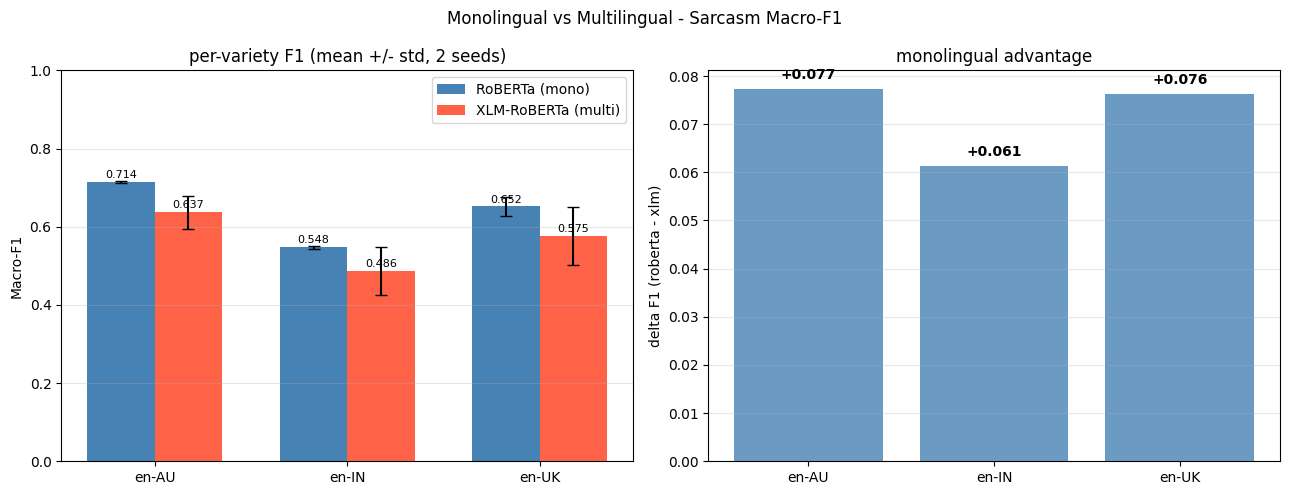

In [22]:
rob_means = [np.mean([r["var_res"][v]["macro_f1"] for r in all_runs["RoBERTa-base"]]) for v in VARIETIES]
xlm_means = [np.mean([r["var_res"][v]["macro_f1"] for r in all_runs["XLM-RoBERTa-base"]]) for v in VARIETIES]
rob_stds = [np.std([r["var_res"][v]["macro_f1"] for r in all_runs["RoBERTa-base"]]) for v in VARIETIES]
xlm_stds = [np.std([r["var_res"][v]["macro_f1"] for r in all_runs["XLM-RoBERTa-base"]]) for v in VARIETIES]

x = np.arange(len(VARIETIES))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Monolingual vs Multilingual - Sarcasm Macro-F1")

b1 = ax1.bar(x - 0.175, rob_means, 0.35, yerr=rob_stds, capsize=4, label="RoBERTa (mono)", color="steelblue")
b2 = ax1.bar(x + 0.175, xlm_means, 0.35, yerr=xlm_stds, capsize=4, label="XLM-RoBERTa (multi)", color="tomato")
ax1.set_xticks(x); ax1.set_xticklabels(VARIETIES)
ax1.set_ylim(0, 1.0); ax1.set_ylabel("Macro-F1")
ax1.legend(); ax1.grid(axis="y", alpha=0.3)
ax1.set_title("per-variety F1 (mean +/- std, 2 seeds)")
for b in list(b1) + list(b2):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", fontsize=8)

deltas = [r - x for r, x in zip(rob_means, xlm_means)]
ax2.bar(VARIETIES, deltas, color="steelblue", alpha=0.8)
ax2.set_ylabel("delta F1 (roberta - xlm)")
ax2.set_title("monolingual advantage")
ax2.grid(axis="y", alpha=0.3)
for i, d in enumerate(deltas):
    ax2.text(i, d + 0.002, f"+{d:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/comparison.png", bbox_inches="tight")
plt.show()


In [23]:
for mname, runs in all_runs.items():
    best = max(runs, key=lambda r: r["val_f1"])
    print(f"{mname} (seed={best['seed']}, val={best['val_f1']:.4f})")
    print("-" * 50)
    for v in VARIETIES:
        if v not in best["var_res"]: continue
        rep = best["var_res"][v]["report"]
        mf1 = best["var_res"][v]["macro_f1"]
        print(f"  {v}  f1={mf1:.4f}")
        for cls in LABEL_NAMES:
            if cls in rep:
                r = rep[cls]
                print(f"    {cls}: P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1-score']:.3f} n={r['support']:.0f}")
        print()


RoBERTa-base (seed=555, val=0.7189)
--------------------------------------------------
  en-AU  f1=0.7112
    Not Sarcastic: P=0.812 R=0.892 F1=0.850 n=471
    Sarcastic: P=0.660 R=0.505 F1=0.572 n=196

  en-IN  f1=0.5437
    Not Sarcastic: P=0.939 R=0.911 F1=0.925 n=760
    Sarcastic: P=0.139 R=0.196 F1=0.163 n=56

  en-UK  f1=0.6751
    Not Sarcastic: P=0.974 R=0.869 F1=0.918 n=647
    Sarcastic: P=0.309 R=0.717 F1=0.432 n=53

XLM-RoBERTa-base (seed=90210, val=0.6734)
--------------------------------------------------
  en-AU  f1=0.6793
    Not Sarcastic: P=0.800 R=0.858 F1=0.828 n=471
    Sarcastic: P=0.586 R=0.485 F1=0.531 n=196

  en-IN  f1=0.5480
    Not Sarcastic: P=0.948 R=0.836 F1=0.888 n=760
    Sarcastic: P=0.144 R=0.375 F1=0.208 n=56

  en-UK  f1=0.6494
    Not Sarcastic: P=0.963 R=0.878 F1=0.918 n=647
    Sarcastic: P=0.282 R=0.585 F1=0.380 n=53



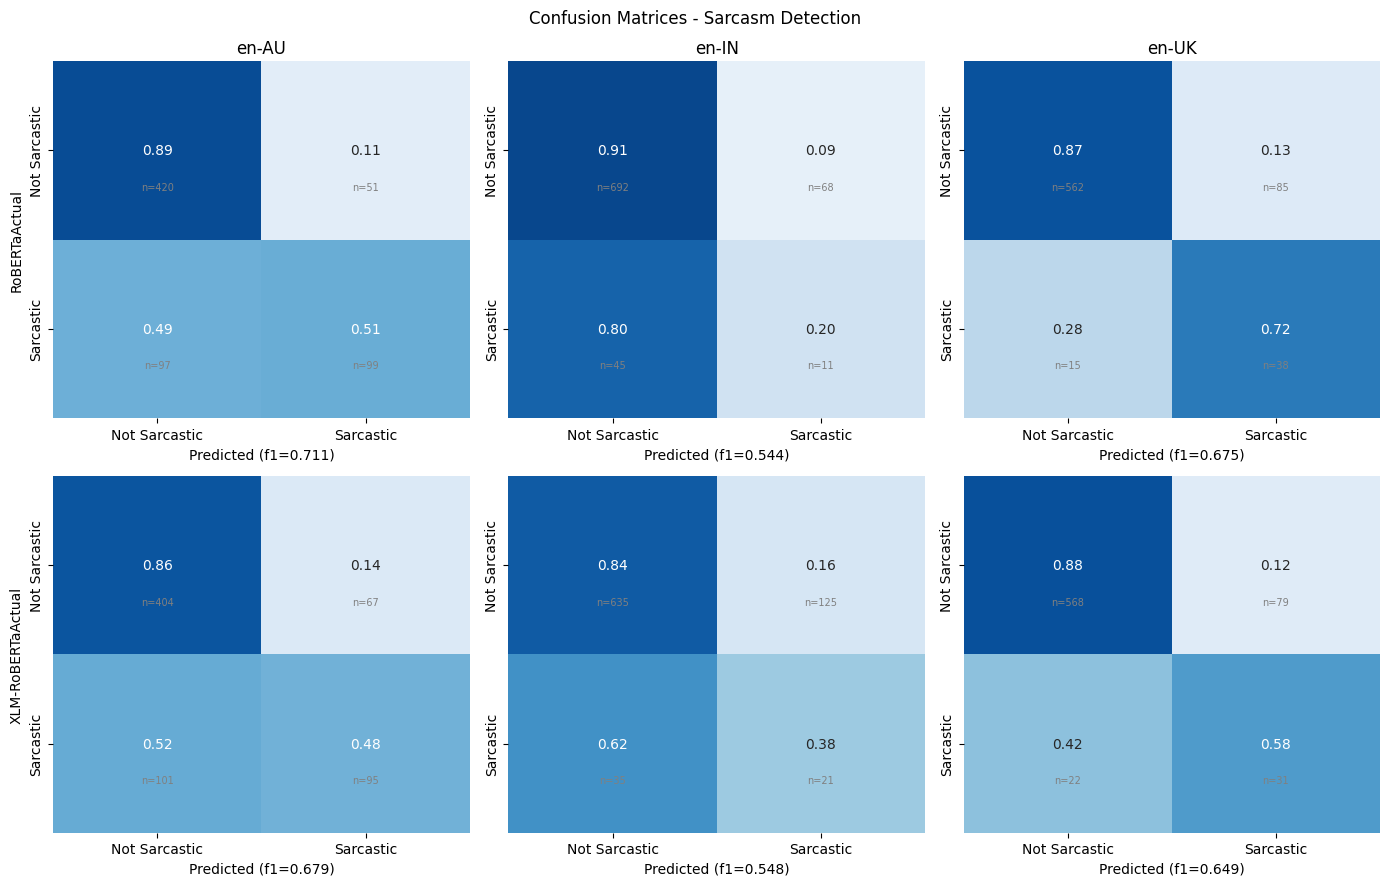

In [24]:
best_rob = max([roberta_run1, roberta_run2], key=lambda r: r["val_f1"])
best_xlm = max([xlm_run1, xlm_run2], key=lambda r: r["val_f1"])

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Confusion Matrices - Sarcasm Detection")

for ri, (run, name) in enumerate([(best_rob, "RoBERTa"), (best_xlm, "XLM-RoBERTa")]):
    for ci, v in enumerate(VARIETIES):
        ax = axes[ri][ci]
        res = run["var_res"][v]
        cm = confusion_matrix(res["labels"], res["preds"], labels=[0, 1])
        cm_n = cm.astype("float") / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_n, ax=ax, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, vmin=0, vmax=1, cbar=False)
        for i in range(2):
            for j in range(2):
                ax.text(j+0.5, i+0.72, f"n={cm[i,j]}", ha="center", fontsize=7, color="gray")
        if ri == 0: ax.set_title(v)
        if ci == 0: ax.set_ylabel(name + "Actual")
        ax.set_xlabel(f"Predicted (f1={res['macro_f1']:.3f})")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/confusion_matrices.png", bbox_inches="tight")
plt.show()


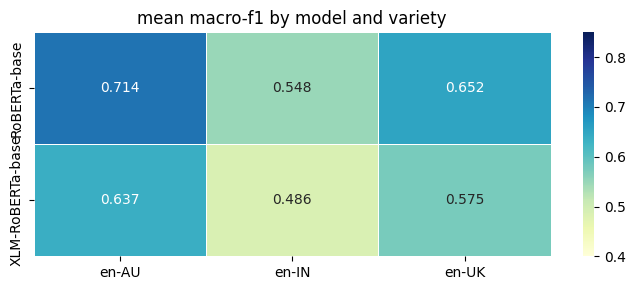

In [25]:
heat = {mname: {v: np.mean([r["var_res"][v]["macro_f1"] for r in runs]) for v in VARIETIES}
        for mname, runs in all_runs.items()}

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pd.DataFrame(heat).T, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax, linewidths=0.5, vmin=0.4, vmax=0.85)
ax.set_title("mean macro-f1 by model and variety")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/f1_heatmap.png", bbox_inches="tight")
plt.show()


RoBERTa: avg 3.0min
XLM-R:   avg 14.0min


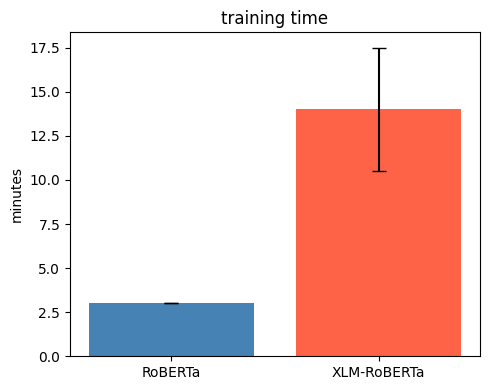

In [26]:
rob_times = [roberta_run1["mins"], roberta_run2["mins"]]
xlm_times = [xlm_run1["mins"], xlm_run2["mins"]]
print(f"RoBERTa: avg {np.mean(rob_times):.1f}min")
print(f"XLM-R:   avg {np.mean(xlm_times):.1f}min")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["RoBERTa", "XLM-RoBERTa"],
       [np.mean(rob_times), np.mean(xlm_times)],
       yerr=[np.std(rob_times), np.std(xlm_times)],
       capsize=5, color=["steelblue", "tomato"])
ax.set_ylabel("minutes")
ax.set_title("training time")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/training_time.png")
plt.show()


---
## 9. Error Analysis — Code-Mixed Misclassifications

We inspect **where the monolingual model failed but the multilingual succeeded** (and vice versa) on the **en-IN test set**, focusing on code-mixed tokens.  
This section contributes evidence to whether multilingual pre-training specifically helps with code-mixed sarcasm signals.

> **Note:** Full LIME/SHAP-based error analysis (Section 4 of the report) should be run on the encoder output separately — this section provides the manual qualitative layer.


In [27]:
d = raw["en-IN"]["test"]
tc = find_col(d.features, ["text", "sentence", "review", "comment"])
lc = find_col(d.features, ["Sarcasm", "sarcasm_label", "sarcasm", "label"])
texts = d[tc]
true_l = [int(x) for x in d[lc]]

rob_preds = best_rob["var_res"]["en-IN"]["preds"]
xlm_preds = best_xlm["var_res"]["en-IN"]["preds"]

print("roberta wrong, xlm correct:")
n = 0
for i in range(min(len(texts), len(rob_preds), len(xlm_preds))):
    if rob_preds[i] != true_l[i] and xlm_preds[i] == true_l[i]:
        hw = [w for w in hindi_words if w in texts[i].lower().split()]
        print(f"  [{i}] true={LABEL_NAMES[true_l[i]]}")
        print(f"       {texts[i][:100]}")
        if hw: print(f"       hindi: {hw}")
        n += 1
        if n >= 10: break

print("roberta correct, xlm wrong:")
n = 0
for i in range(min(len(texts), len(rob_preds), len(xlm_preds))):
    if rob_preds[i] == true_l[i] and xlm_preds[i] != true_l[i]:
        print(f"  [{i}] true={LABEL_NAMES[true_l[i]]}")
        print(f"       {texts[i][:100]}")
        n += 1
        if n >= 8: break


roberta wrong, xlm correct:
  [24] true=Not Sarcastic
       In a room full of idiots and wise men, the idiots scream the loudest.
  [85] true=Not Sarcastic
       anymore left? Please move it out of western countries. There is a huge financial storm coming for th
  [88] true=Sarcastic
       My boi writing scripts
  [114] true=Sarcastic
       See guys, we're winning on multiple fronts /s
  [115] true=Sarcastic
       -9999999 social credit score
  [116] true=Sarcastic
       I was eating mangoes when I read the news. I think that would be the last time I ever ate mangoes
  [120] true=Not Sarcastic
       Tho iske sir pe kyu nahi lagi
       hindi: ['nahi']
  [131] true=Sarcastic
       Now we can scan a QR code to send them aid when the Chinese loans have to be paid back, what an idea
  [151] true=Not Sarcastic
       Jeet lo le phele chutiye.
  [169] true=Sarcastic
       Someone tried to throw Arnoob out mid flight.
Sauce: Kunal Kamra mere speed dial pe hai
/s
       hindi: ['hai']

In [28]:
res = best_rob["var_res"]["en-IN"]
d = raw["en-IN"]["test"]
texts = d[find_col(d.features, ["text", "sentence", "review", "comment"])]
true_l = [int(x) for x in d[find_col(d.features, ["Sarcasm", "sarcasm_label", "sarcasm", "label"])]]

print("false negatives - sarcastic missed by roberta (en-IN):")
n = 0
for i, (p, t) in enumerate(zip(res["preds"], true_l)):
    if t == 1 and p == 0:
        hw = [w for w in hindi_words if w in texts[i].lower().split()]
        print(f"  [{i}] {texts[i][:100]}")
        if hw: print(f"       {hw}")
        n += 1
        if n >= 10: break

print(f"total: {sum(1 for p,t in zip(res['preds'], true_l) if t==1 and p==0)}")


false negatives - sarcastic missed by roberta (en-IN):
  [26] parampara pratistha anusaasan by RSS, do the worst to the society and say RAM RAM at the end.
  [48] Shhhh  "Ashwariya se jalte hai sab". She is an angel she can do nothing wrong.
       ['hai']
  [66] Koi na essay likh kar le aana ghar se.
       ['ghar']
  [88] My boi writing scripts
  [94] Even day: we never discriminated against South Indians, it is anti nationals who spread fake news.
O
  [114] See guys, we're winning on multiple fronts /s
  [115] -9999999 social credit score
  [116] I was eating mangoes when I read the news. I think that would be the last time I ever ate mangoes
  [125] lol you know it's Gauri Khan designs when you see long, green plant pots everywhere
  [131] Now we can scan a QR code to send them aid when the Chinese loans have to be paid back, what an idea
total: 45


## Discussion

The headline result is that RoBERTa beat XLM-RoBERTa on average across all three varieties, which wasn't what I expected going in. But the picture is more interesting than that when you actually look at the numbers.

The tokenisation showed XLM handles some Hindi words better. "bahut" comes out as a single token in XLM (['bahut']) but two fragments in RoBERTa (['bah', 'ut']), same with "bhai". But not every Hindi word benefits, "yaar" still splits into two tokens in both models, so the advantage is only partial.

Looking at the overall macro-F1 averages, RoBERTa wins across the board:

| Model | en-AU | en-IN | en-UK | Overall |
|-------|-------|-------|-------|---------|
| RoBERTa-base | 0.714 | 0.548 | 0.652 | 0.666 |
| XLM-RoBERTa | 0.637 | 0.486 | 0.575 | 0.583 |

But the XLM average is dragged down by the seed 555 run which was pretty bad (val F1 of 0.51). If you just compare the seed 90210 runs, en-IN is basically a draw. RoBERTa 0.5518 vs XLM 0.5480, a gap of 0.004.

The more interesting finding is in the per-class breakdown for en-IN. XLM has much better recall on the sarcastic class: 0.375 vs 0.196. That means XLM correctly identified nearly twice as many sarcastic examples in Indian English. The overall macro-F1 looks similar because XLM's "Not Sarcastic" accuracy drops at the same time, but in terms of actually catching sarcasm in code-mixed text, which is what the brief was asking about, XLM does show a real advantage there.

So the actual answer to the brief's question is yes, the multilingual model does handle code-mixed en-IN sarcasm better in one meaningful way, just not in the way the overall F1 number suggests. The bigger problem for both models is how hard en-IN is regardless. Only 56 sarcastic examples in 816 test cases, and a lot of the sarcasm needs cultural context to detect. Things like "My boi writing scripts" or references to Gauri Khan require knowing what those references are actually about.

On en-UK, XLM actually slightly outperforms RoBERTa in the seed 90210 run (0.649 vs 0.628), which suggests the larger model capacity helps even for standard English sometimes.

The XLM seed variance is also a problem. The two runs gave 0.51 and 0.67 on validation. RoBERTa was much more consistent at 0.72 and 0.68. XLM seems more sensitive to random initialisation when the classes are imbalanced like this.

Training time is worth noting too. XLM averaged 14 minutes per run vs 3 minutes for RoBERTa. For the gain in sarcasm recall on en-IN, that is a big difference.

In [29]:
pd.DataFrame(rows).to_csv(OUTPUT_DIR + "/results.csv", index=False)
print("saved to", OUTPUT_DIR)


saved to ./outputs_2_3


In [30]:
print("roberta: https://huggingface.co/reachaki/besstie-roberta-sarcasm")
print("xlm:     https://huggingface.co/reachaki/besstie-xlm-roberta-sarcasm")


roberta: https://huggingface.co/reachaki/besstie-roberta-sarcasm
xlm:     https://huggingface.co/reachaki/besstie-xlm-roberta-sarcasm
